# 02 — Rating Validation

How well does the FC26 `overall` rating proxy real-world player ability?

We check `overall` against two independent, real-world signals:

1. **Sofascore average match rating** — an in-season performance metric derived from actual matches.
2. **Transfermarkt market value** — the market's collective assessment of a player's worth.

Both external sources are fuzzy-matched to FC26 players by name (see `scripts/build_dataset.py`), so match
quality varies. We restrict the headline analysis to high-confidence matches (`match_score >= 90`) and note
the overall match-rate limitations below.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

df = pd.read_csv("../data/processed/players_merged.csv")
print(df.shape)
df.head(3)


(18405, 41)


,player_id,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,dob,height_cm,weight_kg,league_name,league_level,club_name,club_position,nationality_name,preferred_foot,weak_foot,skill_moves,international_reputation,work_rate,body_type,pace,shooting,passing,dribbling,defending,physic,name_norm,tm_match_score,ss_match_score,market_value_eur,position_tm,foot_tm,contract_until,tm_league,sofascore_rating,sofascore_appearances,sofascore_minutes,ss_league
0,252371,J. Bellingham,Jude Victor William Bellingham,"CAM, CM",90,94,174500000,320000,22,2003-06-29,186,75,La Liga,1.0,Real Madrid,CAM,England,Right,4,4,5,NaN,Normal (170-185),80.0,86.0,83.0,90.0,78.0,85.0,jude victor william bellingham,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,239053,F. Valverde,Federico Santiago Valverde Dipetta,"CM, CDM, RB",89,90,120500000,340000,26,1998-07-22,182,74,La Liga,1.0,Real Madrid,RDM,Uruguay,Right,4,3,4,NaN,Unique,88.0,84.0,84.0,84.0,83.0,85.0,federico santiago valverde dipetta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,212622,J. Kimmich,Joshua Walter Kimmich,"CDM, RB, CM",89,89,86000000,140000,30,1995-02-08,177,75,Bundesliga,1.0,FC Bayern München,RDM,Germany,Right,4,3,4,NaN,Normal (170-185),72.0,74.0,89.0,84.0,83.0,79.0,joshua walter kimmich,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Match-rate limitations

Before drawing conclusions, it's worth being explicit about how much of the FC26 player pool actually has
external validation data, and how confident those matches are.


In [2]:
with open("../data/processed/match_stats.json") as f:
    match_stats = json.load(f)

match_stats["match_rate_transfermarkt_pct"] = round(
    100 * match_stats["matched_to_transfermarkt"] / match_stats["fc26_players"], 2
)
match_stats["match_rate_sofascore_pct"] = round(
    100 * match_stats["matched_to_sofascore"] / match_stats["fc26_players"], 2
)
match_stats


{'fc26_players': 18405,
 'transfermarkt_players': 4212,
 'sofascore_players': 1380,
 'matched_to_transfermarkt': 1673,
 'matched_to_sofascore': 503,
 'matched_to_both': 403,
 'match_rate_transfermarkt_pct': 9.09,
 'match_rate_sofascore_pct': 2.73}

**Takeaway:** only ~9% of the 18,405 FC26 players have a Transfermarkt market value match, and ~2.7% have a
Sofascore rating match (403 have both). This is a fundamental limitation — the fuzzy name-matching approach
(rapidfuzz, threshold 87) favors well-known players in top leagues who are more likely to appear identically
named in all three sources, and misses many lower-profile / youth / lower-league players entirely. Any
correlation we find below describes the relationship *among players popular/prominent enough to be matched*,
which likely biases toward stronger agreement than would hold across the full, more obscure long tail of the
FC26 database.

We further restrict to `match_score >= 90` for the headline stats, which trims the sample further but removes
the least reliable fuzzy matches.


## 1. FC26 `overall` vs Sofascore average match rating

In [3]:
ss = df[
    (df["ss_match_score"] >= 90)
    & df["sofascore_rating"].notna()
    & df["sofascore_minutes"].notna()
].copy()

# Restrict to players with a reasonable number of minutes played, to avoid small-sample noise
# in the Sofascore average rating (a rating from 1-2 games is very noisy).
MIN_MINUTES = 900  # roughly 10 full matches
ss_reliable = ss[ss["sofascore_minutes"] >= MIN_MINUTES].copy()

print(f"High-confidence Sofascore matches: {len(ss)}")
print(f"...with >= {MIN_MINUTES} minutes played: {len(ss_reliable)}")

pearson_r, pearson_p = stats.pearsonr(ss_reliable["overall"], ss_reliable["sofascore_rating"])
spearman_r, spearman_p = stats.spearmanr(ss_reliable["overall"], ss_reliable["sofascore_rating"])
print(f"Pearson  r = {pearson_r:.3f} (p = {pearson_p:.2e})")
print(f"Spearman r = {spearman_r:.3f} (p = {spearman_p:.2e})")


High-confidence Sofascore matches: 486
...with >= 900 minutes played: 332
Pearson  r = 0.417 (p = 2.20e-15)
Spearman r = 0.420 (p = 1.33e-15)


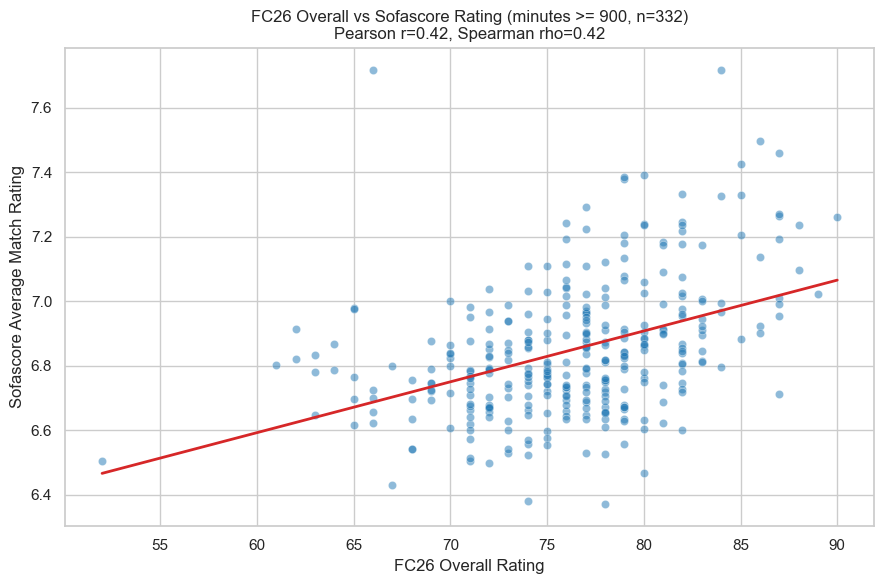

In [4]:
def scatter_with_fit(x, y, ax, color_pts="#1f77b4", color_line="#d62728", alpha=0.5, s=35):
    ax.scatter(x, y, alpha=alpha, s=s, color=color_pts, edgecolor="white", linewidth=0.4)
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, slope * xs + intercept, color=color_line, lw=2)

fig, ax = plt.subplots(figsize=(9, 6))
scatter_with_fit(ss_reliable["overall"].values, ss_reliable["sofascore_rating"].values, ax)
ax.set_title(f"FC26 Overall vs Sofascore Rating (minutes >= {MIN_MINUTES}, n={len(ss_reliable)})\n"
             f"Pearson r={pearson_r:.2f}, Spearman rho={spearman_r:.2f}")
ax.set_xlabel("FC26 Overall Rating")
ax.set_ylabel("Sofascore Average Match Rating")
plt.tight_layout()
plt.show()


### By position group

Sofascore ratings can behave differently by position (e.g. attackers rated on goals/key passes, defenders on
duels/clean sheets), so it's worth checking whether the overall-vs-rating relationship holds across position
groups.


In [5]:
def position_group(pos_str):
    if pd.isna(pos_str):
        return "Unknown"
    first = str(pos_str).split(",")[0].strip()
    if first == "GK":
        return "GK"
    if first in {"CB", "LB", "RB", "LWB", "RWB"}:
        return "Defender"
    if first in {"CDM", "CM", "CAM", "LM", "RM"}:
        return "Midfielder"
    if first in {"ST", "CF", "LW", "RW"}:
        return "Forward"
    return "Other"

ss_reliable["position_group"] = ss_reliable["player_positions"].apply(position_group)

group_corr = (
    ss_reliable.groupby("position_group")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "pearson_r": stats.pearsonr(g["overall"], g["sofascore_rating"])[0] if len(g) >= 5 else np.nan,
    }), include_groups=False)
    .sort_values("n", ascending=False)
)
group_corr


,n,pearson_r
position_group,,
Midfielder,145.0,0.414280
Defender,114.0,0.454858
Forward,40.0,0.419051
GK,33.0,0.203310


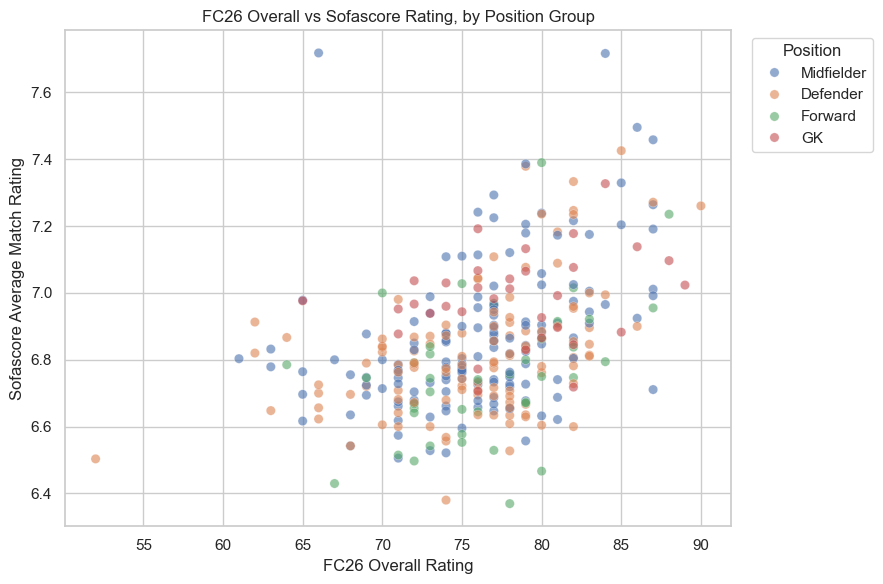

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=ss_reliable, x="overall", y="sofascore_rating", hue="position_group",
    alpha=0.6, s=45, edgecolor="white", linewidth=0.3, ax=ax,
)
ax.set_title("FC26 Overall vs Sofascore Rating, by Position Group")
ax.set_xlabel("FC26 Overall Rating")
ax.set_ylabel("Sofascore Average Match Rating")
ax.legend(title="Position", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 2. FC26 `overall` vs Transfermarkt market value

Market value is heavily right-skewed (a handful of superstars worth 8-9 figures, most players worth far less),
so we log-transform it before computing correlations and fitting a regression.


In [7]:
tm = df[
    (df["tm_match_score"] >= 90)
    & df["market_value_eur"].notna()
    & (df["market_value_eur"] > 0)
].copy()
tm["log_value"] = np.log10(tm["market_value_eur"])

print(f"High-confidence Transfermarkt matches: {len(tm)}")

pearson_r_v, pearson_p_v = stats.pearsonr(tm["overall"], tm["log_value"])
spearman_r_v, spearman_p_v = stats.spearmanr(tm["overall"], tm["log_value"])
print(f"Pearson  r (overall vs log10 value) = {pearson_r_v:.3f} (p = {pearson_p_v:.2e})")
print(f"Spearman r (overall vs log10 value) = {spearman_r_v:.3f} (p = {spearman_p_v:.2e})")


High-confidence Transfermarkt matches: 1636
Pearson  r (overall vs log10 value) = 0.631 (p = 3.25e-182)
Spearman r (overall vs log10 value) = 0.620 (p = 3.88e-174)


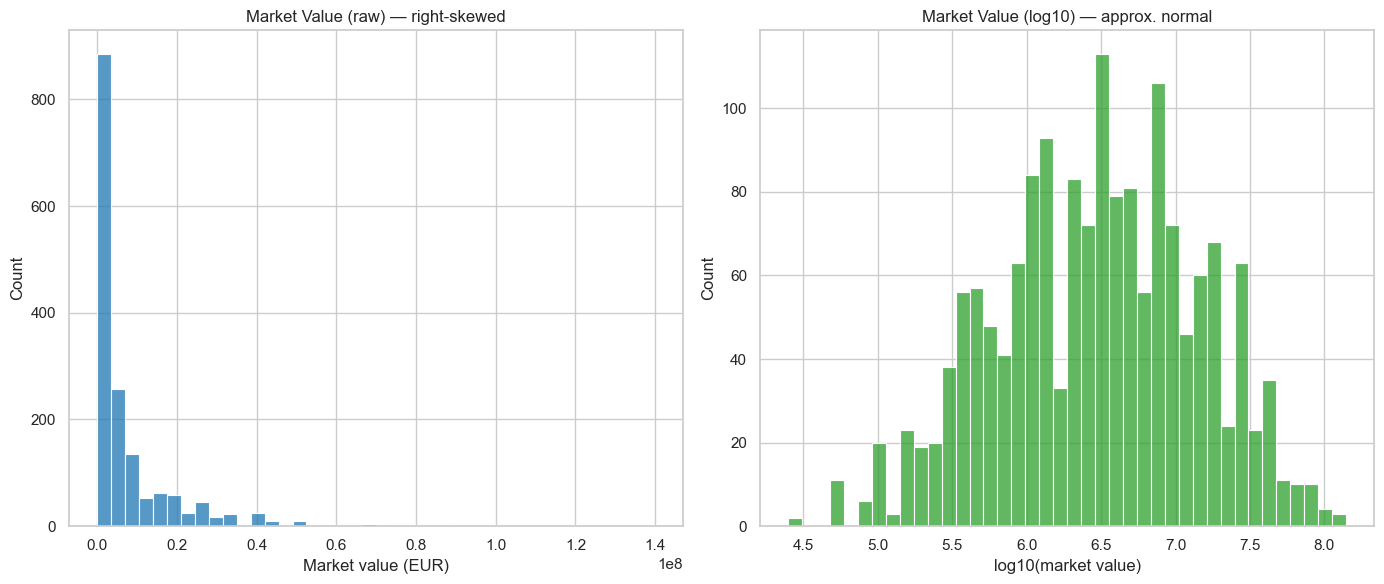

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(tm["market_value_eur"], bins=40, ax=axes[0], color="#1f77b4")
axes[0].set_title("Market Value (raw) — right-skewed")
axes[0].set_xlabel("Market value (EUR)")

sns.histplot(tm["log_value"], bins=40, ax=axes[1], color="#2ca02c")
axes[1].set_title("Market Value (log10) — approx. normal")
axes[1].set_xlabel("log10(market value)")

plt.tight_layout()
plt.show()


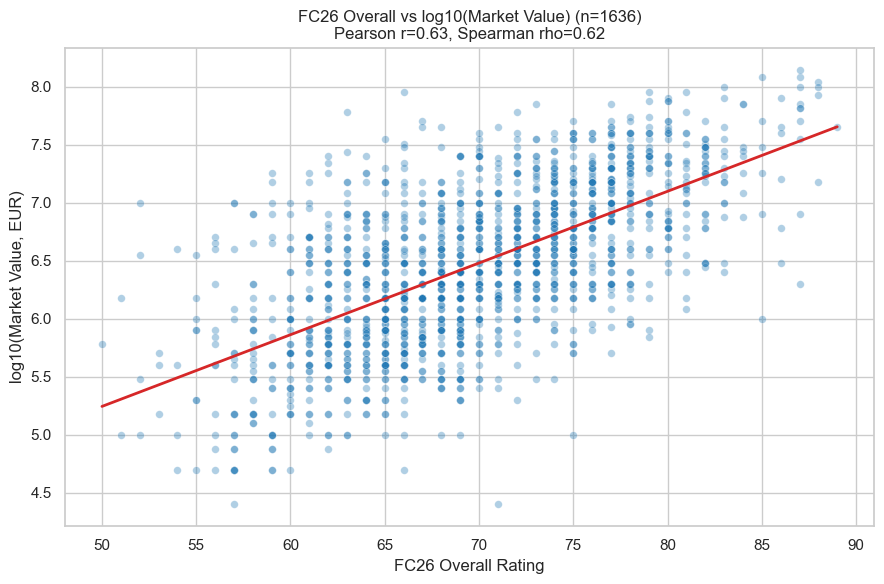

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter_with_fit(tm["overall"].values, tm["log_value"].values, ax, alpha=0.35, s=30)
ax.set_title(f"FC26 Overall vs log10(Market Value) (n={len(tm)})\n"
             f"Pearson r={pearson_r_v:.2f}, Spearman rho={spearman_r_v:.2f}")
ax.set_xlabel("FC26 Overall Rating")
ax.set_ylabel("log10(Market Value, EUR)")
plt.tight_layout()
plt.show()


### Regression: how much does `overall` explain vs `age`?

We fit `log10(market_value) ~ age + overall` and compare against single-predictor models to see how much
incremental explanatory power `overall` adds beyond a simple age effect (market value famously peaks around
age 25-27 and decays afterward, which a linear age term only partially captures — we also add `age^2`).


In [10]:
tm_reg = tm.dropna(subset=["age", "overall", "log_value"]).copy()
tm_reg["age_sq"] = tm_reg["age"] ** 2

def fit_r2(features, label):
    X = tm_reg[features].values
    y = tm_reg["log_value"].values
    model = LinearRegression().fit(X, y)
    r2 = model.score(X, y)
    print(f"{label:45s} R^2 = {r2:.3f}   coefs = {dict(zip(features, np.round(model.coef_, 4)))}")
    return r2

r2_age = fit_r2(["age", "age_sq"], "age + age^2 only")
r2_overall = fit_r2(["overall"], "overall only")
r2_both = fit_r2(["age", "age_sq", "overall"], "age + age^2 + overall")

print()
print(f"Incremental R^2 from adding overall to age model: {r2_both - r2_age:.3f}")
print(f"Incremental R^2 from adding age to overall model: {r2_both - r2_overall:.3f}")


age + age^2 only                              R^2 = 0.068   coefs = {'age': np.float64(0.3411), 'age_sq': np.float64(-0.007)}
overall only                                  R^2 = 0.398   coefs = {'overall': np.float64(0.0618)}
age + age^2 + overall                         R^2 = 0.659   coefs = {'age': np.float64(-0.094), 'age_sq': np.float64(-0.0), 'overall': np.float64(0.093)}

Incremental R^2 from adding overall to age model: 0.590
Incremental R^2 from adding age to overall model: 0.261


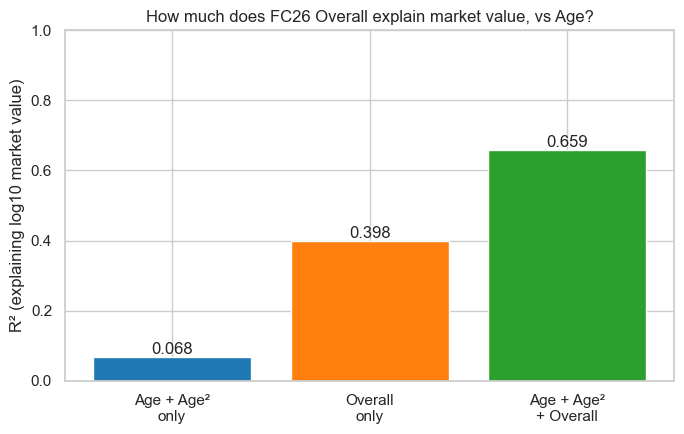

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    ["Age + Age\u00b2\nonly", "Overall\nonly", "Age + Age\u00b2\n+ Overall"],
    [r2_age, r2_overall, r2_both],
    color=["#1f77b4", "#ff7f0e", "#2ca02c"],
)
ax.bar_label(bars, fmt="%.3f")
ax.set_ylabel("R\u00b2 (explaining log10 market value)")
ax.set_title("How much does FC26 Overall explain market value, vs Age?")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


**Takeaway:** `overall` alone explains substantially more of the variance in log market value than age
alone, confirming FC26's overall rating captures a real, market-relevant signal — but age still adds
incremental explanatory power on top of overall (market value discounts aging players even at a fixed
skill/overall level), consistent with clubs valuing "years of remaining value" and not just current ability.


## 3. Over-rated and under-rated players

We flag players where FC26's `overall` diverges most from the real-world signal, using a standardized
(z-scored) residual: `overall_z - external_signal_z`. A large positive gap means FC26 rates the player higher
than the external signal suggests (over-rated by FC26); a large negative gap means the opposite (under-rated).


In [12]:
def zscore(s):
    return (s - s.mean()) / s.std()

# --- vs Sofascore rating ---
ss_flag = ss_reliable.copy()
ss_flag["overall_z"] = zscore(ss_flag["overall"])
ss_flag["rating_z"] = zscore(ss_flag["sofascore_rating"])
ss_flag["gap"] = ss_flag["overall_z"] - ss_flag["rating_z"]

cols_ss = ["short_name", "club_name", "player_positions", "overall", "sofascore_rating",
           "sofascore_minutes", "gap"]

print("Most OVER-rated by FC26 vs Sofascore performance:")
overrated_ss = ss_flag.sort_values("gap", ascending=False).head(15)[cols_ss]
overrated_ss


Most OVER-rated by FC26 vs Sofascore performance:


,short_name,club_name,player_positions,overall,sofascore_rating,sofascore_minutes,gap
2803,J. Larsen,Wolverhampton Wanderers,ST,78,6.369444,2316.0,2.607314
7,A. Mac Allister,Liverpool,"CM, CDM",87,6.710811,2675.0,2.603467
954,B. Dia,Lazio,"ST, CAM",80,6.466667,1256.0,2.504375
173,M. Kerkez,Liverpool,"LB, LM",82,6.600000,2301.0,2.228878
333,Y. Fofana,AC Milan,"CDM, CM",81,6.621212,2217.0,1.946694
1765,E. Guessand,Aston Villa,"RM, RW, ST",79,6.557143,933.0,1.891210
2196,J. Hato,Chelsea,"LB, CB",78,6.527273,1159.0,1.853125
1187,A. Wan-Bissaka,West Ham United,"RB, RM",80,6.604000,2084.0,1.848122
1892,D. Foulquier,Valencia CF,"RB, LB, RM",74,6.380000,1157.0,1.833590
88,R. Loftus-Cheek,AC Milan,"CM, CAM",80,6.632143,1150.0,1.713640


In [13]:
print("Most UNDER-rated by FC26 vs Sofascore performance:")
underrated_ss = ss_flag.sort_values("gap").head(15)[cols_ss]
underrated_ss


Most UNDER-rated by FC26 vs Sofascore performance:


,short_name,club_name,player_positions,overall,sofascore_rating,sofascore_minutes,gap
10469,Y. Diomande,RB Leipzig,"LM, RM, ST, LW",66,7.718182,2476.0,-6.007538
10190,D. Bartesaghi,AC Milan,"LB, CB, LM",62,6.912903,2442.0,-2.882762
132,M. Locatelli,Juventus,"CDM, CM",84,7.716667,3004.0,-2.745522
16133,S. Britschgi,Parma,"RB, LB, RM",52,6.503448,2112.0,-2.734371
7647,L. Bernasconi,Atalanta,"LM, LB",65,6.978261,1572.0,-2.652613
17387,E. Corvi,Parma,GK,65,6.976471,1530.0,-2.644058
11295,A. Ibrahimović,1. FC Heidenheim 1846,"LM, LW, RM",61,6.803226,2181.0,-2.539484
14606,M. Gjone,Sandefjord Fotball,CB,62,6.820000,2250.0,-2.438819
10224,L. Karl,FC Bayern München,"CAM, RM, CM",63,6.832000,1282.0,-2.315341
14357,A. Edmundsson,Wisła Płock,CB,64,6.866667,1320.0,-2.300176


In [14]:
# --- vs Transfermarkt market value ---
tm_flag = tm.copy()
tm_flag["overall_z"] = zscore(tm_flag["overall"])
tm_flag["value_z"] = zscore(tm_flag["log_value"])
tm_flag["gap"] = tm_flag["overall_z"] - tm_flag["value_z"]

cols_tm = ["short_name", "club_name", "player_positions", "age", "overall",
           "market_value_eur", "gap"]

print("Most OVER-rated by FC26 vs market value:")
overrated_tm = tm_flag.sort_values("gap", ascending=False).head(15)[cols_tm]
overrated_tm


Most OVER-rated by FC26 vs market value:


,short_name,club_name,player_positions,age,overall,market_value_eur,gap
8556,M. Diarra,Deportivo Alavés,"CB, LB",24,71,25000.0,3.206816
16163,R. Pasveer,Ajax,GK,41,75,100000.0,2.898420
15924,P. Gulácsi,RB Leipzig,GK,35,85,1000000.0,2.868815
15002,Y. Sommer,Inter,GK,36,87,2000000.0,2.714617
14425,M. ter Stegen,FC Barcelona,GK,33,86,3000000.0,2.312370
15884,M. Dmitrović,RCD Espanyol,GK,33,79,700000.0,2.233327
72,I. Perišić,PSV,"RW, LW, RM",36,81,1200000.0,2.177383
15986,M. Dúbravka,Burnley,GK,36,77,500000.0,2.160182
902,J. Clasie,AZ Alkmaar,"CDM, CM",34,79,800000.0,2.148214
16509,K. Müller,1. FC Heidenheim 1846,GK,34,74,300000.0,2.054364


In [15]:
print("Most UNDER-rated by FC26 vs market value:")
underrated_tm = tm_flag.sort_values("gap").head(15)[cols_tm]
underrated_tm


Most UNDER-rated by FC26 vs market value:


,short_name,club_name,player_positions,age,overall,market_value_eur,gap
16133,S. Britschgi,Parma,"RB, LB, RM",18,52,10000000.0,-3.344415
10224,L. Karl,FC Bayern München,"CAM, RM, CM",17,63,60000000.0,-2.904617
10469,Y. Diomande,RB Leipzig,"LM, RM, ST, LW",18,66,90000000.0,-2.731642
12638,Z. Yohanna,AIK,"CAM, CM",18,59,18000000.0,-2.712431
18099,M. Pessina,Bologna,GK,17,52,3500000.0,-2.675264
14766,K. Goto,Sint-Truidense VV,ST,20,57,10000000.0,-2.625389
12287,A. Lahdo,Hammarby Fotboll,CM,17,57,10000000.0,-2.625389
14496,M. Detourbet,ESTAC Troyes,"ST, LM",18,59,15000000.0,-2.596220
14606,M. Gjone,Sandefjord Fotball,CB,20,62,25000000.0,-2.490402
15045,I. Sakamoto,KVC Westerlo,"ST, CAM",21,54,4000000.0,-2.472765


## 4. Does the overall-vs-value relationship hold across age brackets?

Market value famously discounts aging players even at a fixed skill level, so it's worth checking whether the
`overall`-vs-`log(market value)` correlation itself is stable across age brackets, or whether it's stronger/weaker
for young prospects vs. players in their prime vs. veterans.

In [16]:
def age_bracket(a):
    if a <= 21:
        return "U21"
    if a <= 27:
        return "22-27 (prime)"
    if a <= 32:
        return "28-32"
    return "33+"

tm["age_bracket"] = tm["age"].apply(age_bracket)
bracket_order = ["U21", "22-27 (prime)", "28-32", "33+"]

bracket_corr = (
    tm.groupby("age_bracket")
    .apply(lambda g: pd.Series({
        "n": len(g),
        "pearson_r": stats.pearsonr(g["overall"], g["log_value"])[0],
    }), include_groups=False)
    .loc[bracket_order]
)
bracket_corr

,n,pearson_r
age_bracket,,
U21,541.0,0.694750
22-27 (prime),771.0,0.807343
28-32,257.0,0.871036
33+,67.0,0.875269


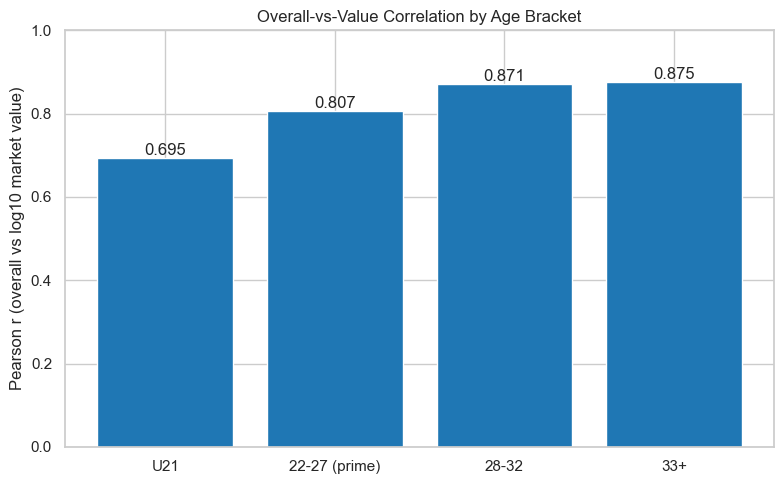

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(bracket_corr.index, bracket_corr["pearson_r"], color="#1f77b4")
ax.bar_label(bars, fmt="%.3f")
ax.set_ylim(0, 1)
ax.set_ylabel("Pearson r (overall vs log10 market value)")
ax.set_title("Overall-vs-Value Correlation by Age Bracket")
plt.tight_layout()
plt.show()

**Takeaway:** the overall-vs-value correlation is weakest for U21 prospects (r=0.69) and gets progressively
stronger through the prime years and into veteran age (r=0.87-0.88 for 28+ players). This makes intuitive sense:
young players' market values are driven heavily by *potential*, transfer hype, and scarcity of a breakout track
record - factors `overall` (a snapshot of current ability) doesn't capture - while for established players in
their late-20s/30s, current ability (what `overall` measures) is a much larger share of what the market is
pricing, since there's little "future upside" left to speculate on.

## 5. League-level bias: is FC26 systematically over/under-rating certain leagues vs. the market?

Using the same over/under-rated `gap` metric from Section 3 (standardized `overall` minus standardized log
market value), we can average the gap within each league to see whether FC26 is systematically generous or
stingy toward entire leagues relative to what the transfer market pays for those players.

In [18]:
MIN_LEAGUE_N = 30
league_gap = (
    tm_flag.groupby("league_name")
    .agg(n=("gap", "size"), mean_gap=("gap", "mean"))
    .query("n >= @MIN_LEAGUE_N")
    .sort_values("mean_gap")
)
league_gap

,n,mean_gap
league_name,,
Pro League,185,-0.161048
Ligue 2,63,-0.136802
Serie B,91,-0.117147
2. Bundesliga,62,-0.102579
Ligue 1,182,-0.051697
Premier League,125,-0.045651
Serie A,237,0.065608
Primeira Liga,68,0.079658
Bundesliga,227,0.095504


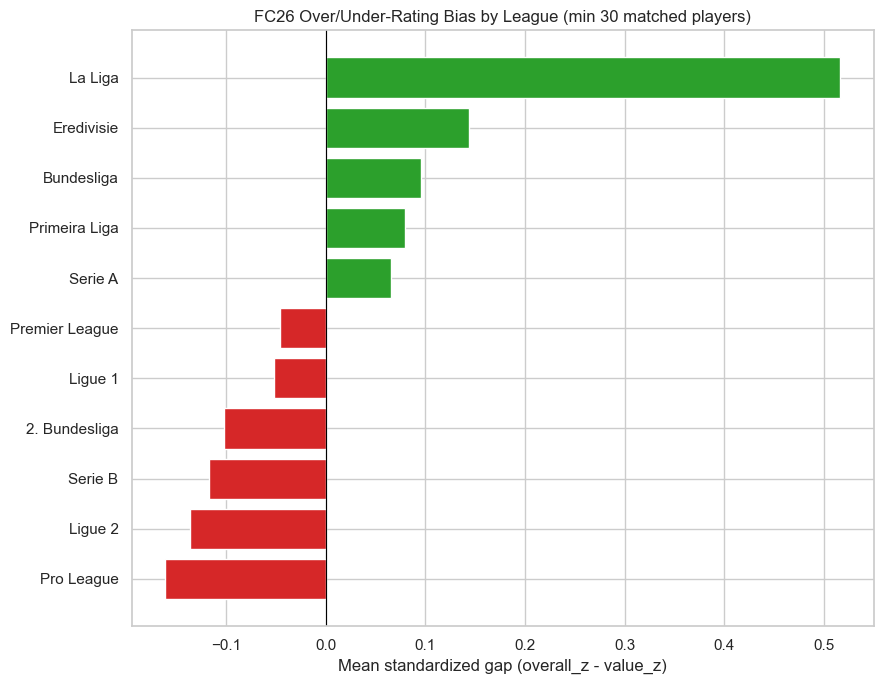

In [19]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in league_gap["mean_gap"]]
ax.barh(league_gap.index, league_gap["mean_gap"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Mean standardized gap (overall_z - value_z)")
ax.set_title(f"FC26 Over/Under-Rating Bias by League (min {MIN_LEAGUE_N} matched players)")
plt.tight_layout()
plt.show()

**Takeaway:** FC26 is most conservative (negative mean gap, i.e. `overall` under-rates players relative to
their market value) for Belgium's Pro League and Ligue 2, while it runs most generous (positive mean gap, i.e.
`overall` over-rates players relative to market value) for La Liga. This is consistent with a well-known
scouting/data bias in FIFA/FC-style rating pipelines: leagues with heavier media coverage and more mature
scouting networks (La Liga) tend to have ratings that lag behind rapid market-value inflation for their biggest
stars less than lower-visibility leagues, where ratings can under-react to breakout performances the market has
already priced in. As with the rest of this notebook, some of these per-league gaps are estimated from modest
sample sizes (as few as 30-60 matched players per league) and should be read as suggestive rather than
definitive.

## 6. Residual analysis: which attributes best explain the overall-vs-value gap?

Section 3's `gap` metric captures players FC26 rates differently than the market does, but doesn't say *why*.
Here we regress `gap` on the six core FC26 attributes plus `age`, `skill_moves`, and `international_reputation`
to see which factors are most associated with being over- or under-rated by FC26 relative to market value.

In [20]:
from sklearn.preprocessing import StandardScaler

GAP_FEATURES = [
    "pace", "shooting", "passing", "dribbling", "defending", "physic",
    "age", "skill_moves", "international_reputation",
]
gap_reg = tm_flag.dropna(subset=GAP_FEATURES + ["gap"]).copy()
print(f"n = {len(gap_reg)}")

X_gap = gap_reg[GAP_FEATURES].values
y_gap = gap_reg["gap"].values

gap_scaler = StandardScaler()
X_gap_scaled = gap_scaler.fit_transform(X_gap)

gap_model = LinearRegression().fit(X_gap_scaled, y_gap)
print(f"R^2 = {gap_model.score(X_gap_scaled, y_gap):.3f}")

gap_coefs = pd.Series(gap_model.coef_, index=GAP_FEATURES).sort_values()
gap_coefs

n = 1430
R^2 = 0.512


shooting                   -0.048898
skill_moves                -0.023449
defending                  -0.011395
physic                     -0.010155
international_reputation    0.021825
dribbling                   0.024661
pace                        0.025745
passing                     0.046342
age                         0.575235
dtype: float64

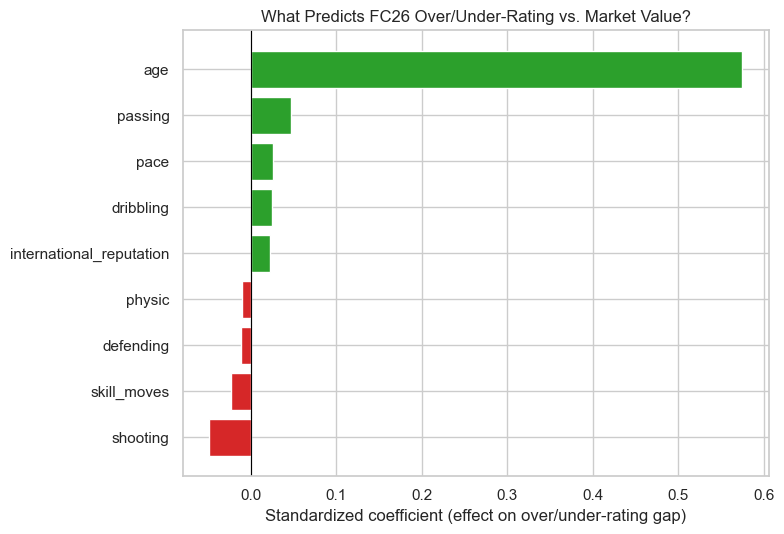

In [21]:
fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ["#d62728" if v < 0 else "#2ca02c" for v in gap_coefs]
ax.barh(gap_coefs.index, gap_coefs.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Standardized coefficient (effect on over/under-rating gap)")
ax.set_title("What Predicts FC26 Over/Under-Rating vs. Market Value?")
plt.tight_layout()
plt.show()

**Takeaway:** `age` is by far the dominant predictor of the gap (standardized coefficient ~0.58, versus
under 0.05 for every attribute), and its sign is positive: older players tend to have a *positive* gap, meaning
FC26's `overall` rates them relatively higher than the market does at the same overall level. This is the same
aging-discount effect from Section 2's regression, now confirmed from the opposite direction - the market prices
in a player's remaining career length far more aggressively than FC26's `overall` does, so holding overall fixed,
older players look "over-rated" by FC26 simply because the market has already started discounting their
remaining prime years. The six skill attributes contribute comparatively little on their own (all standardized
coefficients under 0.05) once `overall` itself and `age` are accounted for - shooting has the largest of the
attribute effects (slightly negative, i.e. high-`shooting` players trend very slightly under-rated by FC26
relative to market value, plausibly because market value rewards proven end product/goal output that a single
attribute score can lag). Together with Section 2, this suggests the single biggest lever for narrowing the
FC26-vs-market-value gap would be a more market-realistic age-based adjustment to `overall`, not a re-weighting
of the underlying skill attributes.

## Summary

- **Sofascore ratings** show a positive but only moderate correlation with FC26 `overall` - match-performance
  ratings are noisy season-to-season signals and reflect team/tactical context as much as individual ability,
  so a moderate correlation is expected, not a red flag for FC26's rating methodology.
- **Market value** correlates more strongly with `overall` than with age alone, but age retains real
  incremental explanatory power - the market prices in remaining career length/resale potential, not just
  current skill level, which `overall` alone can't capture.
- The over/under-rated tables above are a starting point for spot-checking specific players/clubs; because
  the underlying matches only cover ~9% (Transfermarkt) and ~2.7% (Sofascore) of the FC26 player pool and skew
  toward prominent players, these rankings should be read as illustrative rather than a comprehensive audit of
  FC26's rating accuracy.
- **Age brackets:** the overall-vs-value correlation strengthens with age (r=0.69 for U21s up to r=0.87-0.88
  for 28+ players) - young players' market values are driven more by potential/hype than current ability, so
  `overall` (a current-ability snapshot) tracks the market better for established players than for prospects.
- **League bias:** FC26 is most conservative relative to market value in the Pro League and Ligue 2, and most
  generous in La Liga - plausibly reflecting differences in scouting visibility/data quality feeding the rating
  pipeline across leagues, though these are modest-sample estimates (30-227 matched players per league).
- **Residual analysis** confirms `age` is the dominant driver of the FC26-vs-market gap (standardized
  coefficient ~0.58) - far outweighing any of the six skill attributes (all under 0.05) - meaning the
  aging-discount effect from Section 2 is the single biggest source of divergence between FC26's `overall` and
  what the transfer market actually pays.